In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving HR_comma_sep.csv to HR_comma_sep.csv
Saving insurance_data.csv to insurance_data.csv
Saving zoo-class-type.csv to zoo-class-type.csv
Saving zoo-data.csv to zoo-data.csv


In [ ]:
df = pd.read_csv("HR_comma_sep.csv")
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


,0
satisfaction_level,0
last_evaluation,0
number_project,0
average_montly_hours,0
time_spend_company,0
Work_accident,0
left,0
promotion_last_5years,0
Department,0
salary,0


In [ ]:
df['left'].value_counts()
df.groupby('left').mean(numeric_only=True)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


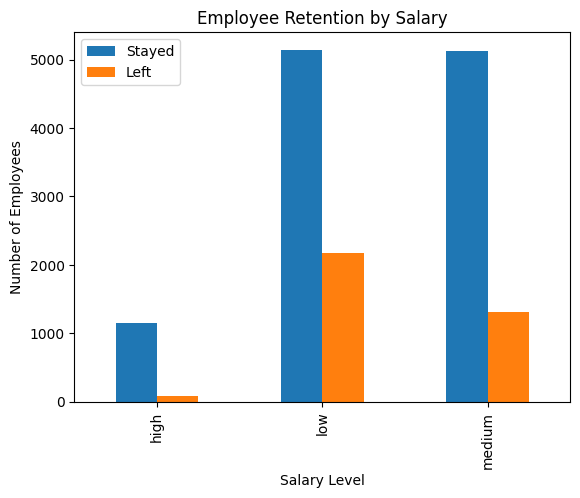

In [ ]:
pd.crosstab(df.salary, df.left).plot(kind='bar')

plt.title("Employee Retention by Salary")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.legend(["Stayed", "Left"])
plt.show()

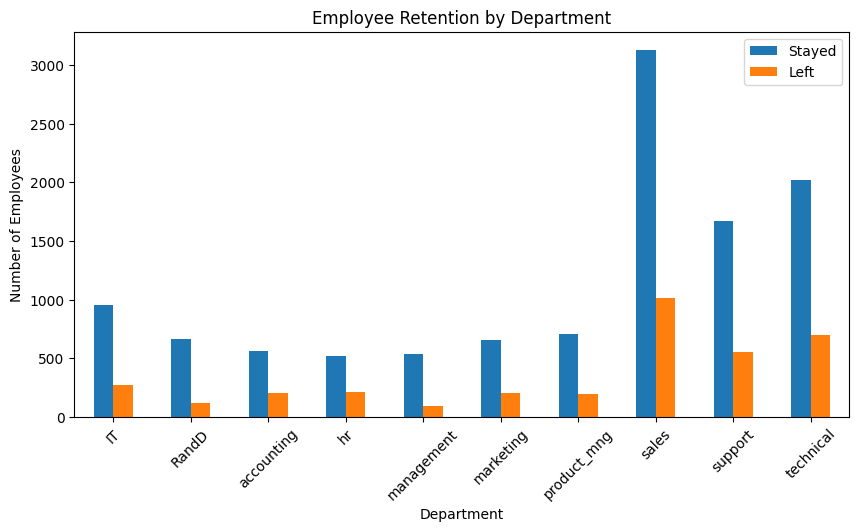

In [ ]:
pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,5))

plt.title("Employee Retention by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.legend(["Stayed", "Left"])
plt.xticks(rotation=45)
plt.show()

In [ ]:
X = df.drop('left', axis=1)

X = pd.get_dummies(X, drop_first=True)

y = df['left']

In [ ]:
scaler = StandardScaler()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.786


[[3170  258]
 [ 705  367]]


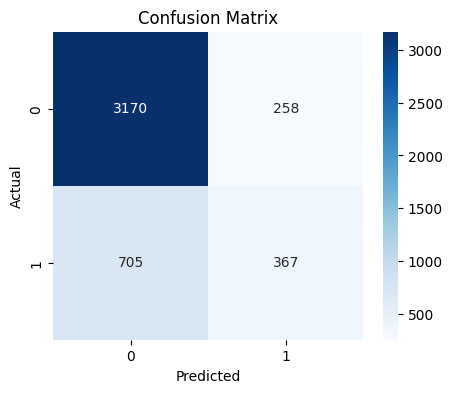

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.87      3428
           1       0.59      0.34      0.43      1072

    accuracy                           0.79      4500
   macro avg       0.70      0.63      0.65      4500
weighted avg       0.76      0.79      0.76      4500



In [ ]:
# MultiClass

In [ ]:
zoo = pd.read_csv("zoo-data.csv")
class_type = pd.read_csv("zoo-class-type.csv")

zoo.head()

,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [ ]:
zoo = zoo.drop("animal_name", axis=1)
zoo.isnull().sum()

,0
hair,0
feathers,0
eggs,0
milk,0
airborne,0
aquatic,0
predator,0
toothed,0
backbone,0
breathes,0


In [ ]:
X = zoo.drop("class_type", axis=1)
y = zoo["class_type"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=3000, multi_class='multinomial')

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=3000, multi_class='multinomial')

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9354838709677419


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        15
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         2
           6       0.83      1.00      0.91         5
           7       1.00      0.67      0.80         3

    accuracy                           0.94        31
   macro avg       0.79      0.81      0.79        31
weighted avg       0.92      0.94      0.92        31



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


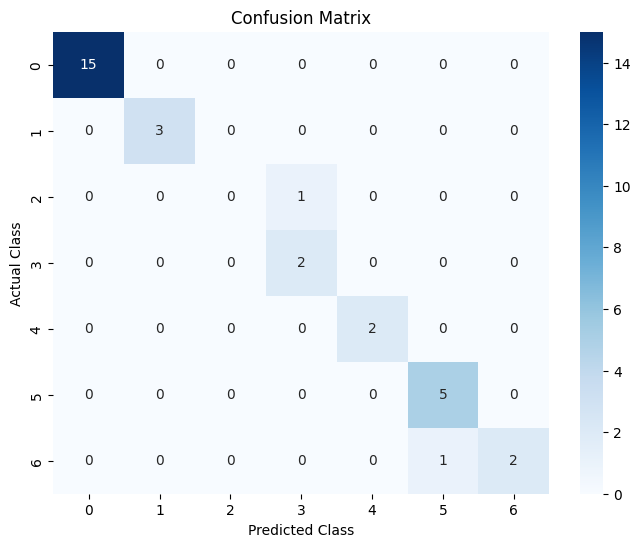

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

Binary Logistic Regression Accuracy: 0.7682512167477832


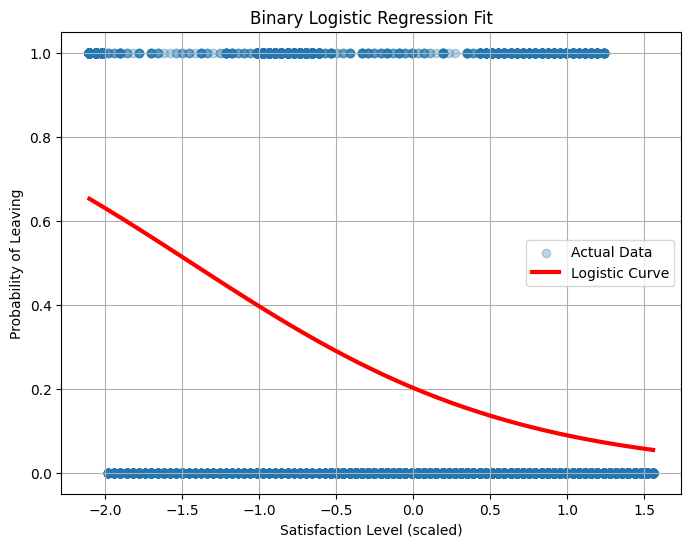

Confusion Matrix:
 [[10589   839]
 [ 2637   934]]


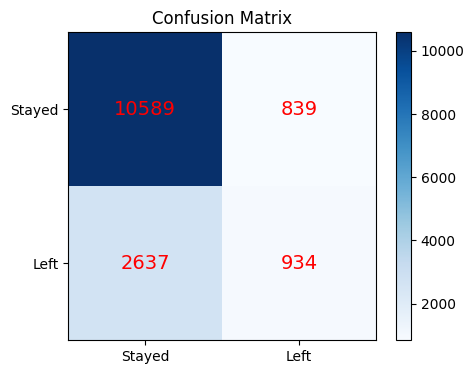

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("HR_comma_sep.csv")
X = df[['satisfaction_level']].values
y = df['left'].values.reshape(-1,1)

X_mean = X.mean()
X_std = X.std()
X_scaled = (X - X_mean)/X_std

X_scaled = np.hstack([np.ones((X_scaled.shape[0],1)), X_scaled])

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

theta = np.zeros((X_scaled.shape[1],1))
alpha = 0.1
iterations = 5000
m = X_scaled.shape[0]

for i in range(iterations):
    z = np.dot(X_scaled, theta)
    h = sigmoid(z)
    gradient = np.dot(X_scaled.T, (h - y)) / m
    theta -= alpha * gradient

y_prob = sigmoid(np.dot(X_scaled, theta))
y_pred = (y_prob >= 0.5).astype(int)

accuracy = np.mean(y_pred == y)
print("Binary Logistic Regression Accuracy:", accuracy)

x_vals = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 300)
x_plot = np.c_[np.ones((300,1)), x_vals.reshape(-1,1)]
y_curve = sigmoid(np.dot(x_plot, theta))

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,1], y, alpha=0.3, label="Actual Data")
plt.plot(x_vals, y_curve, color='red', linewidth=3, label="Logistic Curve")
plt.xlabel("Satisfaction Level (scaled)")
plt.ylabel("Probability of Leaving")
plt.title("Binary Logistic Regression Fit")
plt.legend()
plt.grid(True)
plt.show()

def confusion_matrix_manual(y_true, y_pred):
    tp = np.sum((y_true==1) & (y_pred==1))
    tn = np.sum((y_true==0) & (y_pred==0))
    fp = np.sum((y_true==0) & (y_pred==1))
    fn = np.sum((y_true==1) & (y_pred==0))
    return np.array([[tn, fp],[fn, tp]])

cm = confusion_matrix_manual(y, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title("Confusion Matrix")
plt.xticks([0,1], ["Stayed","Left"])
plt.yticks([0,1], ["Stayed","Left"])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j], ha='center', va='center', color='red', fontsize=14)
plt.show()

Multiclass Logistic Regression Accuracy: 0.9900990099009901
Confusion Matrix:
 [[41  0  0  0  0  0  0]
 [ 0 20  0  0  0  0  0]
 [ 0  1  4  0  0  0  0]
 [ 0  0  0 13  0  0  0]
 [ 0  0  0  0  4  0  0]
 [ 0  0  0  0  0  8  0]
 [ 0  0  0  0  0  0 10]]


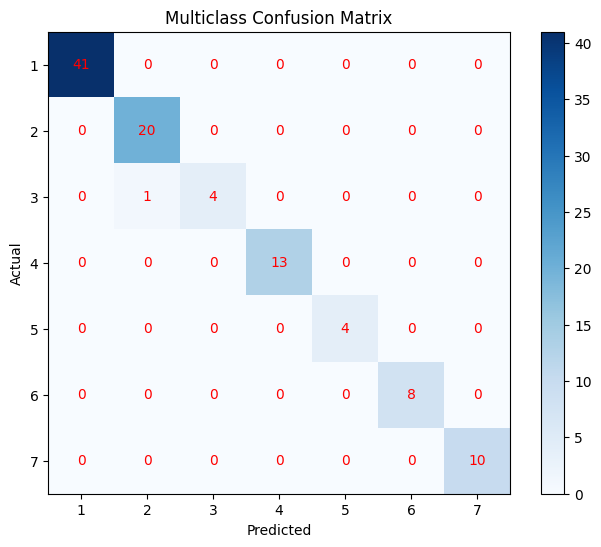

In [ ]:
zoo = pd.read_csv("zoo-data.csv")
X = zoo.drop(['animal_name','class_type'], axis=1).values
y = zoo['class_type'].values

classes = np.unique(y)
num_classes = len(classes)
m, n = X.shape

X = np.hstack([np.ones((m,1)), X])

def sigmoid(z):
    return 1/(1+np.exp(-z))

alpha = 0.1
iterations = 1000

theta = np.zeros((n+1, num_classes))

Y = np.zeros((m, num_classes))
for i, cls in enumerate(classes):
    Y[:,i] = (y==cls).astype(int)

for k in range(num_classes):
    th = np.zeros((n+1,1))
    yk = Y[:,k].reshape(-1,1)
    for i in range(iterations):
        z = np.dot(X, th)
        h = sigmoid(z)
        grad = np.dot(X.T, (h - yk)) / m
        th -= alpha * grad
    theta[:,k] = th.flatten()

prob = sigmoid(np.dot(X, theta))
y_pred = np.argmax(prob, axis=1) + 1

accuracy = np.mean(y_pred == y)
print("Multiclass Logistic Regression Accuracy:", accuracy)

cm = np.zeros((num_classes, num_classes), dtype=int)
for i in range(m):
    cm[y[i]-1, y_pred[i]-1] += 1

print("Confusion Matrix:\n", cm)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.title("Multiclass Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(num_classes), classes)
plt.yticks(range(num_classes), classes)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j,i,cm[i,j], ha='center', va='center', color='red')
plt.show()